In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Варіант 8 — Полтава
city = "Полтава"
months = np.arange(1, 13)

rain = pd.Series(
    [37, 34, 31, 37, 48, 62, 68, 52, 38, 34, 39, 41],
    index=["Січ", "Лют", "Бер", "Кві", "Тра", "Чер",
           "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"]
)

print("Варіант: 8")
print("Місто:", city)
print(rain)

Варіант: 8
Місто: Полтава
Січ    37
Лют    34
Бер    31
Кві    37
Тра    48
Чер    62
Лип    68
Сер    52
Вер    38
Жов    34
Лис    39
Гру    41
dtype: int64


In [3]:
scale_table = pd.DataFrame({
    "Змінна": ["Місто", "Номер місяця", "Кількість опадів"],
    "Шкала": ["Номінальна", "Порядкова", "Відносна"],
    "Коректні міри": [
        "Мода",
        "Медіана, мода",
        "Середнє, медіана, мода"
    ]
})

scale_table

,Змінна,Шкала,Коректні міри
0,Місто,Номінальна,Мода
1,Номер місяця,Порядкова,"Медіана, мода"
2,Кількість опадів,Відносна,"Середнє, медіана, мода"


In [4]:
variation_row = np.sort(rain.values)

print("Варіаційний ряд:")
print(variation_row)

Варіаційний ряд:
[31 34 34 37 37 38 39 41 48 52 62 68]


In [5]:
bins = [30, 40, 50, 60, 70]

freq = pd.cut(
    rain,
    bins=bins,
    right=False,
    labels=["31–39", "40–49", "50–59", "60–69"]
).value_counts().sort_index()

rel_freq = freq / len(rain) * 100
cum_freq = freq.cumsum()

frequency_table = pd.DataFrame({
    "Абсолютна частота": freq,
    "Відносна частота (%)": rel_freq.round(1),
    "Накопичена частота": cum_freq
})

frequency_table

,Абсолютна частота,Відносна частота (%),Накопичена частота
31–39,7,58.3,7
40–49,2,16.7,9
50–59,1,8.3,10
60–69,2,16.7,12


In [6]:
print("Сума частот:", freq.sum())
print("Сума відносних частот:", rel_freq.sum())

Сума частот: 12
Сума відносних частот: 100.0


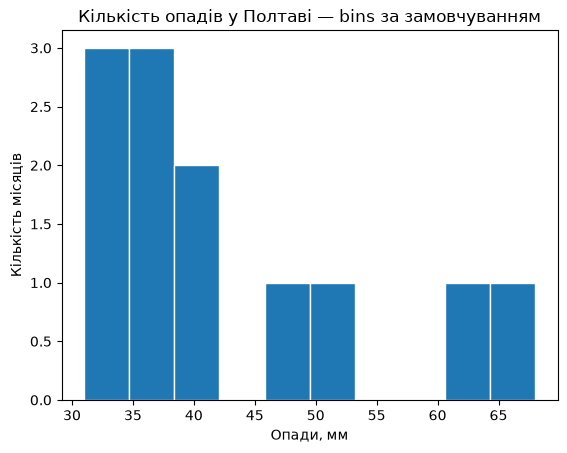

In [7]:
plt.hist(rain, edgecolor="white")
plt.title("Кількість опадів у Полтаві — bins за замовчуванням")
plt.xlabel("Опади, мм")
plt.ylabel("Кількість місяців")
plt.show()

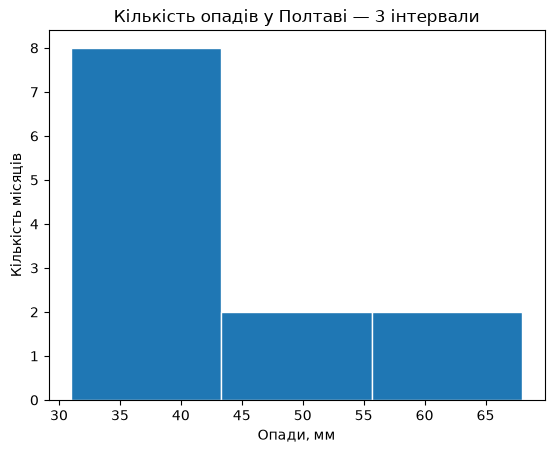

In [8]:
plt.hist(rain, bins=3, edgecolor="white")
plt.title("Кількість опадів у Полтаві — 3 інтервали")
plt.xlabel("Опади, мм")
plt.ylabel("Кількість місяців")
plt.show()

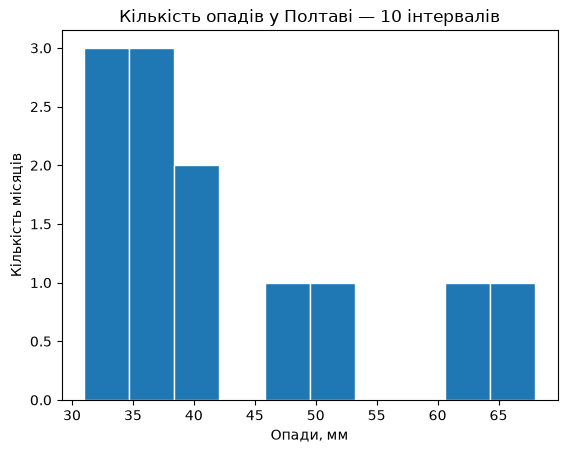

In [9]:
plt.hist(rain, bins=10, edgecolor="white")
plt.title("Кількість опадів у Полтаві — 10 інтервалів")
plt.xlabel("Опади, мм")
plt.ylabel("Кількість місяців")
plt.show()

In [10]:
n = len(rain)

sqrt_bins = np.sqrt(n)
sturges_bins = 1 + np.log2(n)

print("n =", n)
print("Правило √n:", sqrt_bins)
print("Правило Стерджеса:", sturges_bins)

n = 12
Правило √n: 3.4641016151377544
Правило Стерджеса: 4.584962500721156


In [11]:
mean_value = rain.mean()
median_value = rain.median()
mode_value = rain.mode()

q1 = rain.quantile(0.25)
q3 = rain.quantile(0.75)

print("Середнє:", mean_value)
print("Медіана:", median_value)
print("Мода:")
print(mode_value)

print("Q1:", q1)
print("Q3:", q3)

Середнє: 43.416666666666664
Медіана: 38.5
Мода:
0    34
1    37
dtype: int64
Q1: 36.25
Q3: 49.0


In [12]:
summary = pd.DataFrame({
    "Міра": ["Середнє", "Медіана", "Мода", "Q1", "Q3"],
    "Значення": [
        mean_value,
        median_value,
        "34, 37",
        q1,
        q3
    ]
})

summary

,Міра,Значення
0,Середнє,43.416667
1,Медіана,38.5
2,Мода,"34, 37"
3,Q1,36.25
4,Q3,49.0


Завдання 5. Зв'язок зі шкалою вимірювання
Готова відповідь

Кількість опадів у міліметрах належить до відносної шкали вимірювання, оскільки має природний нуль: 0 мм означає відсутність опадів. Для цієї шкали можна виконувати арифметичні операції та порівнювати значення як за різницею, так і за відношенням. Тому для кількості опадів коректними є всі три міри положення: середнє, медіана та мода.

Місто, навпаки, належить до номінальної шкали. Назви міст є лише категоріями і не мають числового порядку. Навіть якщо закодувати міста числами, наприклад Полтава = 1, Київ = 2, Львів = 3, ці числа будуть лише кодами, а не справжніми числовими вимірюваннями. Тому обчислення середнього такого коду не має змісту. Для змінної «місто» коректною мірою положення є тільки мода.

Чотири питання, які потрібно здати
1. Чому середнє некоректне для «місто»?

Середнє арифметичне некоректне для змінної «місто», тому що міста є номінальними категоріями, між якими немає числової відстані. Якщо присвоїти містам числа, ці числа будуть лише умовними кодами. Наприклад, код 3 не означає, що місто втричі «більше» за місто з кодом 1. Тому середнє кодів не має статистичного змісту. Для міста можна визначити моду.

2. Чому номер місяця класифікується неоднозначно?

Номер місяця має природний порядок: січень перед лютим, лютий перед березнем тощо. Також номери місяців мають рівні календарні кроки. Через це їх можна аргументовано розглядати як інтервальну змінну. Проте природного нуля немає: 0-й місяць не означає відсутність місяця. Крім того, календарний цикл переходить від 12-го місяця до 1-го. Тому в цій роботі номер місяця доцільно трактувати як порядкову шкалу.

3. Чому потрібна гістограма, а не стовпчикова діаграма?

Кількість опадів є кількісною змінною, а більшість її значень різні. Якщо побудувати стовпчик для кожного окремого значення, отримаємо багато окремих стовпчиків, що погано показуватимуть загальну форму розподілу. Гістограма об'єднує близькі значення в інтервали та показує, скільки місяців потрапило в кожен інтервал. Тому для аналізу розподілу опадів гістограма є доцільнішою.

4. Що означає накопичена частота третього інтервалу?

Для третього інтервалу накопичена частота дорівнює 10. Це означає, що 10 із 12 місяців мають кількість опадів не більшу за 60 мм. У відсотках це приблизно 83,3% усіх місяців року.